# # Datathon Passos Mágicos — Análise Educacional e Modelo Preditivo

In [41]:
# Análise dos dados da Associação Passos Mágicos (2022–2024), contemplando preparação, limpeza, respostas às 11 perguntas de negócio, modelagem preditiva de risco de defasagem e avaliação do modelo.
# **Divisão temporal:** 2022 e 2023 para treino | 2024 para teste.

# ## 1. Preparação dos Dados



In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11



Carregamento da base consolidada
O parâmetro na_values trata o caractere "—" como valor ausente
Caso ocorra erro de encoding, trocar 'utf-8' por 'latin-1'


In [43]:
df = pd.read_csv('../Dataset/bd_consolid_22_23_24.csv', sep=';', na_values=['—'],
                 encoding='utf-8')

print(f"Dimensões da base: {df.shape}")
df.head()



Dimensões da base: (3030, 47)


,ANO,RA,Fase,Turma,Nome,Ano nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,...,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV,Data de Nasc 23,Escola 2024,Ativo/ Inativo 24,Data de Nasc 24,IPP
0,2022,RA-1,FASE 7,7A,Aluno-1,2003,19,Feminino,2016,Escola Pública,...,Fase 8,-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,NaN,NaN,0
1,2022,RA-2,FASE 7,7A,Aluno-2,2005,17,Feminino,2017,Rede Decisão,...,Fase 7,0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,NaN,NaN,0
2,2022,RA-3,FASE 7,7A,Aluno-3,2005,17,Feminino,2016,Rede Decisão,...,Fase 7,0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,NaN,NaN,NaN,NaN,0
3,2022,RA-4,FASE 7,7A,Aluno-4,2005,17,Masculino,2017,Rede Decisão,...,Fase 7,0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,NaN,NaN,0
4,2022,RA-5,FASE 7,7A,Aluno-5,2005,17,Feminino,2016,Rede Decisão,...,Fase 7,0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,NaN,NaN,0


Padronização dos nomes das colunas
Os nomes originais contêm acentos, espaços e maiúsculas (ex.: "Gênero",
"Instituição de ensino", "Atingiu PV"). A padronização facilita a
manipulação ao longo de todo o notebook.


In [44]:
def padronizar_colunas(col):
    """Converte nomes de colunas para snake_case sem acentos."""
    col = col.strip().lower() 
    substituicoes = {
        'á': 'a', 'â': 'a', 'ã': 'a', 'à': 'a',
        'é': 'e', 'ê': 'e',
        'í': 'i',
        'ó': 'o', 'ô': 'o', 'õ': 'o',
        'ú': 'u', 'û': 'u',
        'ç': 'c',
        ' ': '_', '/': '_', 'º': '', '¹': '1', '²': '2', '³': '3'
    }
    for orig, novo in substituicoes.items():
        col = col.replace(orig, novo)
    col = col.replace('(', '').replace(')', '')
    while '__' in col:
        col = col.replace('__', '_')
    return col

df.columns = [padronizar_colunas(c) for c in df.columns]

print("Colunas após padronização:")
print(df.columns.tolist())

Colunas após padronização:
['ano', 'ra', 'fase', 'turma', 'nome', 'ano_nasc', 'idade', 'genero', 'ano_ingresso', 'instituicao_de_ensino', 'pedra', 'inde', 'inde.1', 'cg', 'cf', 'ct', 'n_av', 'avaliador1', 'recomendacao_av1', 'avaliador2', 'recomendacao_av2', 'avaliador3', 'recomendacao_av3', 'avaliador4', 'recomendacao_av4', 'iaa', 'ieg', 'ips', 'recomendacao_psicologia', 'ida', 'matem', 'portug', 'ingles', 'indicado', 'atingiu_pv', 'ipv', 'ian', 'fase_ideal', 'defas', 'destaque_ieg', 'destaque_ida', 'destaque_ipv', 'data_de_nasc_23', 'escola_2024', 'ativo_inativo_24', 'data_de_nasc_24', 'ipp']


Converte nomes de colunas para snake_case sem acentos.


In [45]:
# Visão geral da estrutura
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 47 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ano                      3030 non-null   int64  
 1   ra                       3030 non-null   object 
 2   fase                     3030 non-null   object 
 3   turma                    3030 non-null   object 
 4   nome                     3030 non-null   object 
 5   ano_nasc                 3030 non-null   int64  
 6   idade                    3030 non-null   int64  
 7   genero                   3030 non-null   object 
 8   ano_ingresso             3030 non-null   int64  
 9   instituicao_de_ensino    3029 non-null   object 
 10  pedra                    2845 non-null   object 
 11  inde                     3030 non-null   object 
 12  inde.1                   3030 non-null   object 
 13  cg                       860 non-null    object 
 14  cf                      

In [46]:
# Contagem de registros por ano
print("Registros por ano:")
print(df['ano'].value_counts().sort_index())



Registros por ano:
ano
2022     860
2023    1014
2024    1156
Name: count, dtype: int64


# ## 2. Limpeza dos Dados



In [47]:
# Colunas numéricas — substituir vírgula por ponto e converter (sem divisão)
cols_numericas = ['iaa', 'ieg', 'ips', 'ida', 'matem', 'portug', 'ingles',
                  'inde', 'ipv', 'ian', 'ipp']

for col in cols_numericas:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"{col}: min={df[col].min():.3f}, max={df[col].max():.3f}")

# Visualizar colunas
print(f"Dimensões da base: {df.shape}")
df.head()

# Conversão de colunas inteiras que não precisam de ajuste decimal
cols_int = ['ano', 'ano_nasc', 'idade', 'ano_ingresso', 'cg', 'cf', 'ct',
            'n_av', 'defas']

for col in cols_int:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].astype('Int64')

print("Conversão de colunas inteiras concluída.")


iaa: min=0.000, max=10.000
ieg: min=0.000, max=10.000
ips: min=0.000, max=10.000
ida: min=0.000, max=10.000
matem: min=0.000, max=10.000
portug: min=0.000, max=10.000
ingles: min=0.000, max=10.000
inde: min=1.000, max=9.531
ipv: min=0.000, max=10.010
ian: min=3.000, max=10.000
ipp: min=0.000, max=10.000
Dimensões da base: (3030, 47)
Conversão de colunas inteiras concluída.


# ### 2.2 Diagnóstico de valores ausentes



In [48]:
ausentes = df.isnull().sum().sort_values(ascending=False)
ausentes_pct = (ausentes / len(df) * 100).round(2)

print("Valores ausentes por coluna:")
print(pd.DataFrame({'Ausentes': ausentes, '% do total': ausentes_pct})
        .head(15))



Valores ausentes por coluna:
                         Ausentes  % do total
cg                           3030      100.00
recomendacao_av4             2586       85.35
atingiu_pv                   2170       71.62
cf                           2170       71.62
recomendacao_av2             2170       71.62
recomendacao_av1             2170       71.62
ct                           2170       71.62
destaque_ipv                 2170       71.62
destaque_ida                 2170       71.62
destaque_ieg                 2170       71.62
indicado                     2170       71.62
recomendacao_psicologia      2170       71.62
recomendacao_av3             2170       71.62
data_de_nasc_23              2016       66.53
avaliador4                   1979       65.31


# ### 2.3 Tratamento de valores ausentes



In [49]:
# Remoção de registros sem identificação do aluno
df = df.dropna(subset=['ra'])

# Imputação de colunas numéricas com a mediana (preserva a distribuição)
colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

for col in colunas_numericas:
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)

print(f"Registros após limpeza: {df.shape[0]}")
print(f"Valores ausentes restantes: {df.isnull().sum().sum()}")



Registros após limpeza: 3030
Valores ausentes restantes: 36352


# ### 2.4 Conversão de tipos categóricos



In [50]:
colunas_categoricas = ['pedra', 'fase', 'turma', 'genero',
                       'instituicao_de_ensino', 'atingiu_pv',
                       'indicado', 'fase_ideal', 'ativo_inativo_24', 'escola_2024']

for col in colunas_categoricas:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("Conversão concluída.")



Conversão concluída.


# ### 2.5 Verificação de duplicatas



In [51]:
duplicatas = df.duplicated(subset=['ra', 'ano']).sum()
print(f"Duplicatas (RA + ano): {duplicatas}")



Duplicatas (RA + ano): 0


# ### 2.6 Criação da variável-alvo


In [52]:
# A coluna `defas` contém valores negativos (aluno defasado), zero (sem
# defasagem) e positivos (adiantado). É criada uma variável binária onde
# 1 indica risco de defasagem (defas < 0) e 0 indica ausência de risco.

In [53]:
df['risco_defasagem'] = (df['defas'] < 0).astype(int)

print("Distribuição da variável risco_defasagem:")
print(df['risco_defasagem'].value_counts(normalize=True).round(4))



Distribuição da variável risco_defasagem:
risco_defasagem
1    0.596
0    0.404
Name: proportion, dtype: float64


In [54]:
# ### 2.7 Verificação de consistência: PEDRA vs INDE
#
# As faixas esperadas são:
# - Quartzo: 2,405 a 5,506
# - Ágata: 5,506 a 6,868
# - Ametista: 6,868 a 8,230
# - Topázio: 8,230 a 9,294

In [55]:
faixas = {
    'Quartzo': (2.405, 5.506),
    'Ágata': (5.506, 6.868),
    'Ametista': (6.868, 8.230),
    'Topázio': (8.230, 9.294)
}

for pedra, (minimo, maximo) in faixas.items():
    subset = df[df['pedra'] == pedra]['inde']
    if len(subset) > 0:
        print(f"{pedra}: esperado [{minimo}, {maximo}] | "
              f"encontrado [{subset.min():.3f}, {subset.max():.3f}]")



Quartzo: esperado [2.405, 5.506] | encontrado [3.032, 5.996]
Ágata: esperado [5.506, 6.868] | encontrado [6.009, 7.028]
Ametista: esperado [6.868, 8.23] | encontrado [7.003, 8.058]
Topázio: esperado [8.23, 9.294] | encontrado [7.999, 9.531]


# ## 3. Análise Exploratória — Respostas às 11 Perguntas



# ### Pergunta 1: Adequação do nível (IAN)
# Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?



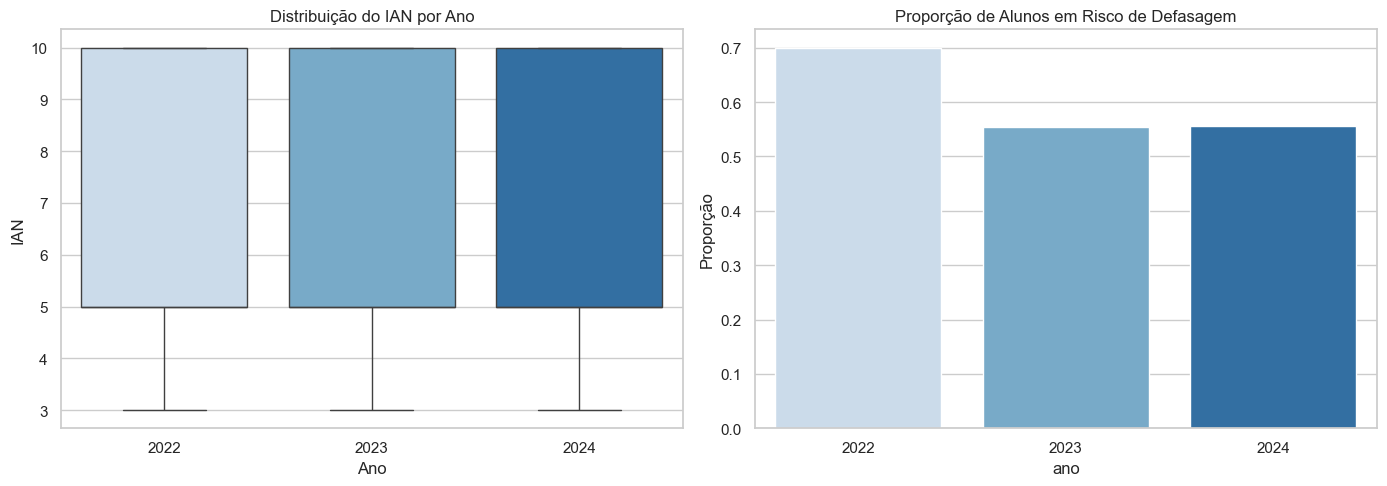


Resumo estatístico do IAN por ano:
          mean       std  min  25%  50%   75%   max
ano                                                
2022  6.440698  2.364359  3.0  5.0  5.0  10.0  10.0
2023  7.197239  2.526963  3.0  5.0  5.0  10.0  10.0
2024  7.187716  2.525072  3.0  5.0  5.0  10.0  10.0


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição do IAN por ano
sns.boxplot(data=df, x='ano', y='ian', ax=axes[0], palette='Blues')
axes[0].set_title('Distribuição do IAN por Ano')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('IAN')

# Proporção de alunos em risco de defasagem por ano
defas_ano = df.groupby('ano')['risco_defasagem'].mean().reset_index()
sns.barplot(data=defas_ano, x='ano', y='risco_defasagem', ax=axes[1],
            palette='Blues')
axes[1].set_title('Proporção de Alunos em Risco de Defasagem')
axes[1].set_ylabel('Proporção')
plt.tight_layout()
plt.show()

print("\nResumo estatístico do IAN por ano:")
print(df.groupby('ano')['ian'].describe()[['mean', 'std', 'min',
                                           '25%', '50%', '75%', 'max']])



# ### Pergunta 2: Desempenho acadêmico (IDA)
# O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo
# ao longo das fases e anos?



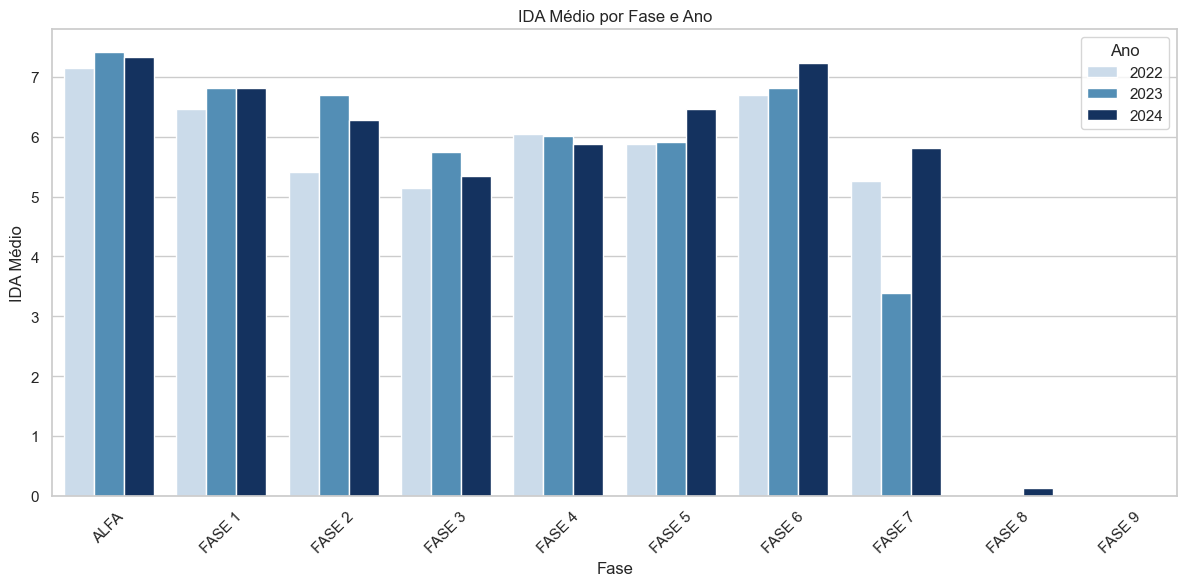


IDA médio por ano:
ano
2022    6.093
2023    6.157
2024    5.809
Name: ida, dtype: float64


In [57]:
ida_fase_ano = df.groupby(['ano', 'fase'])['ida'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=ida_fase_ano, x='fase', y='ida', hue='ano',
            palette=['#c6dbef', '#4292c6','#08306b' ])
plt.title('IDA Médio por Fase e Ano')
plt.xlabel('Fase')
plt.ylabel('IDA Médio')
plt.xticks(rotation=45)
plt.legend(title='Ano')
plt.tight_layout()
plt.show()

print("\nIDA médio por ano:")
print(df.groupby('ano')['ida'].mean().round(3))


# ### Pergunta 3: Engajamento nas atividades (IEG)
# O grau de engajamento (IEG) tem relação direta com IDA e IPV?



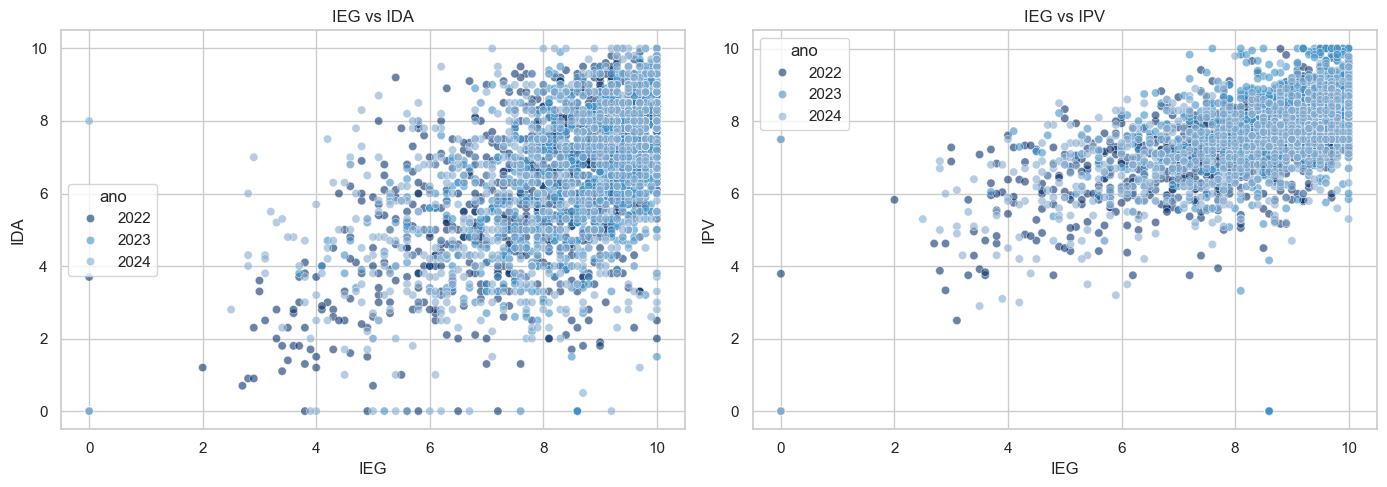


Matriz de correlação IEG, IDA, IPV:
       ieg    ida    ipv
ieg  1.000  0.614  0.637
ida  0.614  1.000  0.752
ipv  0.637  0.752  1.000


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='ieg', y='ida', hue='ano', ax=axes[0],
                alpha=0.6, palette=['#08306b', '#4292c6', "#84abcf"])
axes[0].set_title('IEG vs IDA')
axes[0].set_xlabel('IEG')
axes[0].set_ylabel('IDA')

sns.scatterplot(data=df, x='ieg', y='ipv', hue='ano', ax=axes[1],
                alpha=0.6, palette=['#08306b', '#4292c6', '#84abcf'])
axes[1].set_title('IEG vs IPV')
axes[1].set_xlabel('IEG')
axes[1].set_ylabel('IPV')
plt.tight_layout()
plt.show()

corr_ieg = df[['ieg', 'ida', 'ipv']].corr()
print("\nMatriz de correlação IEG, IDA, IPV:")
print(corr_ieg.round(3))


# ### Pergunta 4: Autoavaliação (IAA)
# As percepções dos alunos (IAA) são coerentes com IDA e IEG?



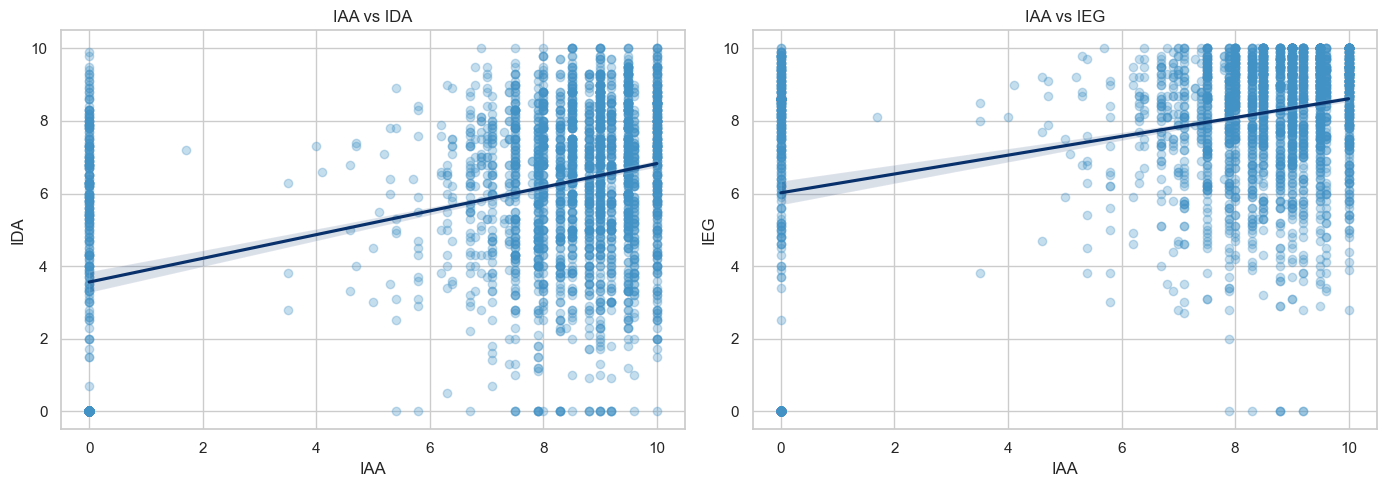


Matriz de correlação IAA, IDA, IEG:
       iaa    ida    ieg
iaa  1.000  0.422  0.381
ida  0.422  1.000  0.614
ieg  0.381  0.614  1.000


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x='iaa', y='ida', ax=axes[0],
            scatter_kws={'alpha': 0.3, 'color': '#4292c6'},
            line_kws={'color': '#08306b'})
axes[0].set_title('IAA vs IDA')
axes[0].set_xlabel('IAA')
axes[0].set_ylabel('IDA')

sns.regplot(data=df, x='iaa', y='ieg', ax=axes[1],
            scatter_kws={'alpha': 0.3, 'color': '#4292c6'},
            line_kws={'color': '#08306b'})
axes[1].set_title('IAA vs IEG')
axes[1].set_xlabel('IAA')
axes[1].set_ylabel('IEG')
plt.tight_layout()
plt.show()

corr_iaa = df[['iaa', 'ida', 'ieg']].corr()
print("\nMatriz de correlação IAA, IDA, IEG:")
print(corr_iaa.round(3))

# ### Pergunta 5: Aspectos psicossociais (IPS)
# Há padrões psicossociais (IPS) que antecedem quedas de desempenho ou engajamento?

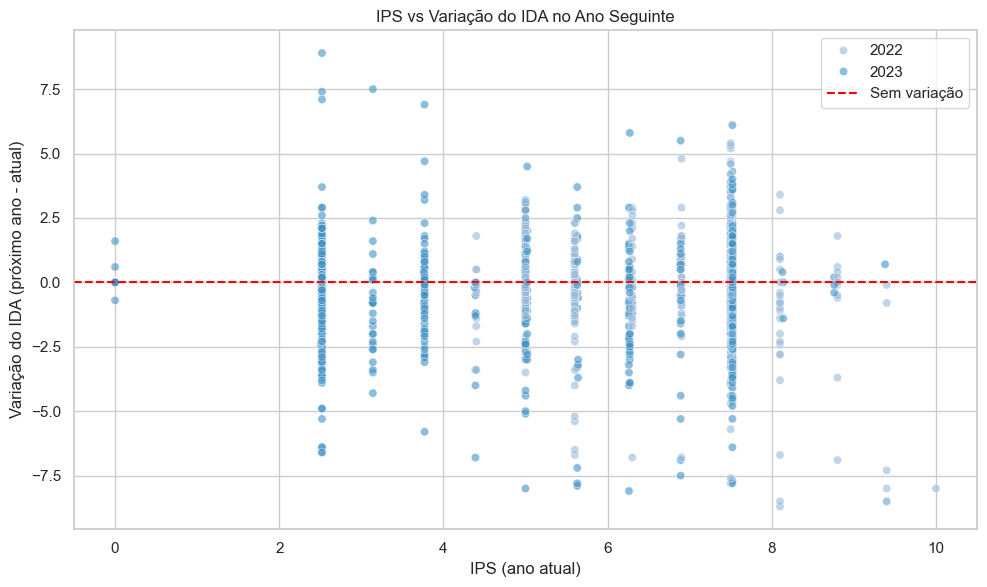


Correlação IPS vs Variação do IDA:
             ips  delta_ida
ips        1.000     -0.007
delta_ida -0.007      1.000


In [60]:
# Construção de visão longitudinal: IPS em t vs variação do IDA em t+1
df_sorted = df.sort_values(['ra', 'ano']).copy()
df_shifted = df_sorted.groupby('ra').shift(-1)

df_sorted['ida_prox_ano'] = df_shifted['ida']
df_sorted['delta_ida'] = df_sorted['ida_prox_ano'] - df_sorted['ida']

# Filtrar apenas registros com ano seguinte disponível
df_long = df_sorted.dropna(subset=['delta_ida'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_long, x='ips', y='delta_ida', hue='ano',
                alpha=0.6, palette=["#98bada", '#4292c6', '#08306b'])
plt.axhline(y=0, color='red', linestyle='--', label='Sem variação')
plt.title('IPS vs Variação do IDA no Ano Seguinte')
plt.xlabel('IPS (ano atual)')
plt.ylabel('Variação do IDA (próximo ano - atual)')
plt.legend()
plt.tight_layout()
plt.show()

corr_ips = df_long[['ips', 'delta_ida']].corr()
print("\nCorrelação IPS vs Variação do IDA:")
print(corr_ips.round(3))



# ### Pergunta 6: Aspectos psicopedagógicos (IPP)
# As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem (IAN)?

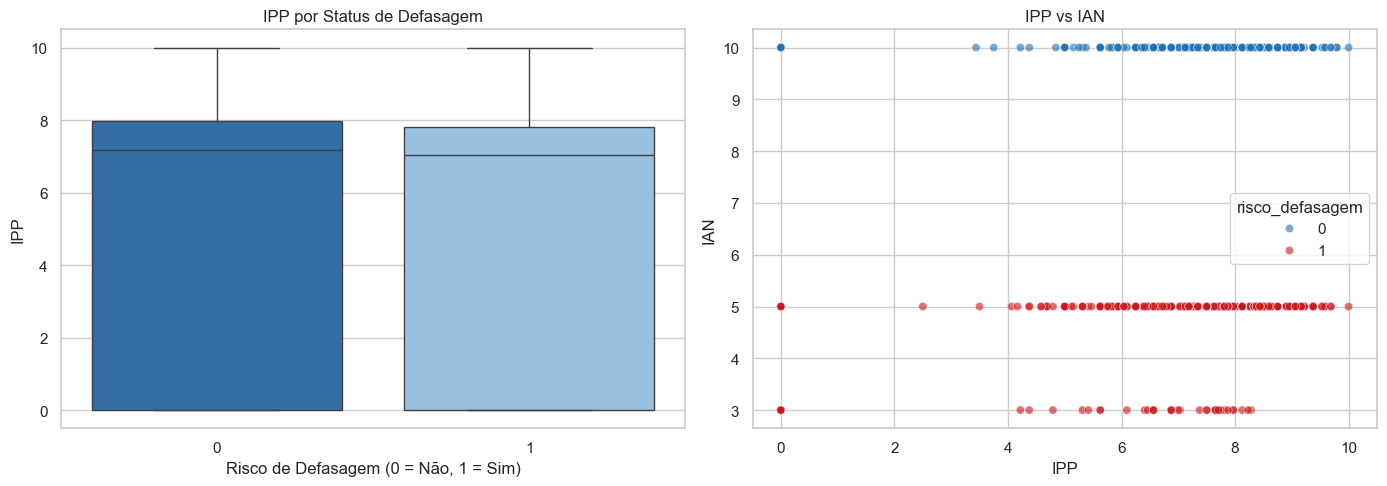


Correlação IPP, IAN, Defasagem:
         ipp    ian  defas
ipp    1.000  0.001  0.026
ian    0.001  1.000  0.854
defas  0.026  0.854  1.000


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='risco_defasagem', y='ipp', ax=axes[0],
            palette=['#2171b5', "#8ec1eb"])
axes[0].set_title('IPP por Status de Defasagem')
axes[0].set_xlabel('Risco de Defasagem (0 = Não, 1 = Sim)')
axes[0].set_ylabel('IPP')

sns.scatterplot(data=df, x='ipp', y='ian', hue='risco_defasagem',
                ax=axes[1], alpha=0.6,
                palette=['#2171b5', '#cb181d'])
axes[1].set_title('IPP vs IAN')
axes[1].set_xlabel('IPP')
axes[1].set_ylabel('IAN')
plt.tight_layout()
plt.show()

corr_ipp = df[['ipp', 'ian', 'defas']].corr()
print("\nCorrelação IPP, IAN, Defasagem:")
print(corr_ipp.round(3))



Atenção: a coluna ipp apresenta valor 0 em todos os registros de 2022,
o que pode indicar que o indicador não era coletado nesse ano.
Esse ponto deve ser considerado na interpretação dos resultados.


# ### Pergunta 7: Ponto de virada (IPV)
# Quais comportamentos — acadêmicos, emocionais ou de engajamento —
# mais influenciam o IPV ao longo do tempo?



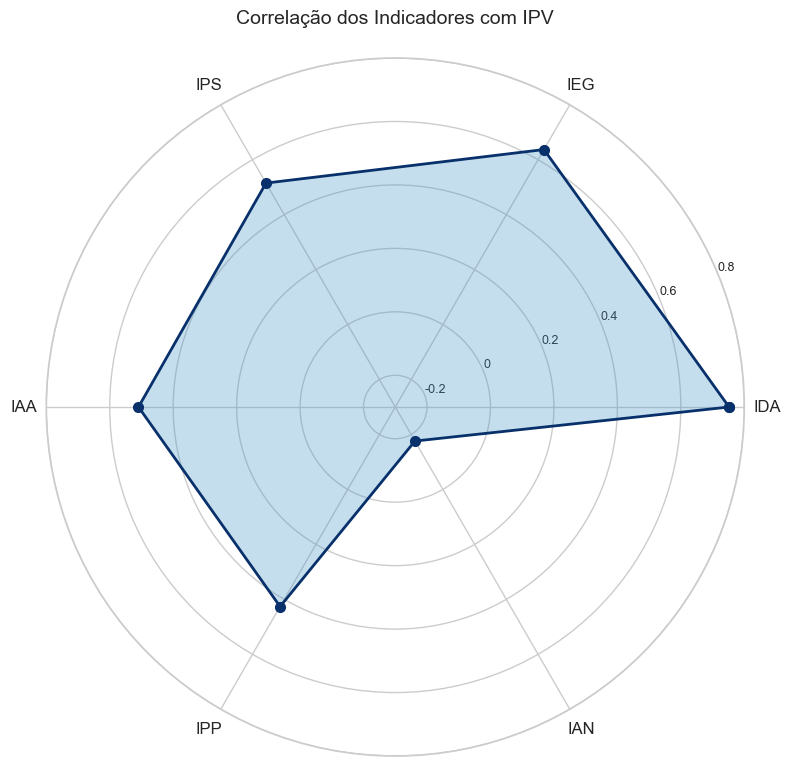


Correlação com IPV (ordenada):
ida    0.752
ieg    0.637
ips    0.515
iaa    0.509
ipp    0.426
ian   -0.176
Name: ipv, dtype: float64


In [62]:
import numpy as np

indicadores = ['ida', 'ieg', 'iaa', 'ips', 'ipp', 'ian']
corr_ipv = df[indicadores + ['ipv']].corr()['ipv'].drop('ipv')
corr_ipv = corr_ipv.sort_values(ascending=False)

# Radar chart
angles = np.linspace(0, 2 * np.pi, len(corr_ipv), endpoint=False).tolist()
values = corr_ipv.values.tolist()
angles += angles[:1]
values += values[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles, values, color='#4292c6', alpha=0.3)
ax.plot(angles, values, color='#08306b', linewidth=2, marker='o',
        markersize=7, markerfacecolor='#08306b')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(corr_ipv.index.str.upper(), fontsize=12)
ax.set_ylim(-0.3, 0.8)
ax.set_yticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['-0.2', '0', '0.2', '0.4', '0.6', '0.8'], fontsize=9)
ax.set_title('Correlação dos Indicadores com IPV', pad=25, fontsize=14)
plt.tight_layout()
plt.show()

print("\nCorrelação com IPV (ordenada):")
print(corr_ipv.round(3))


# ### Pergunta 8: Multidimensionalidade dos indicadores
# Quais combinações de IDA + IEG + IPS + IPP elevam mais o INDE?



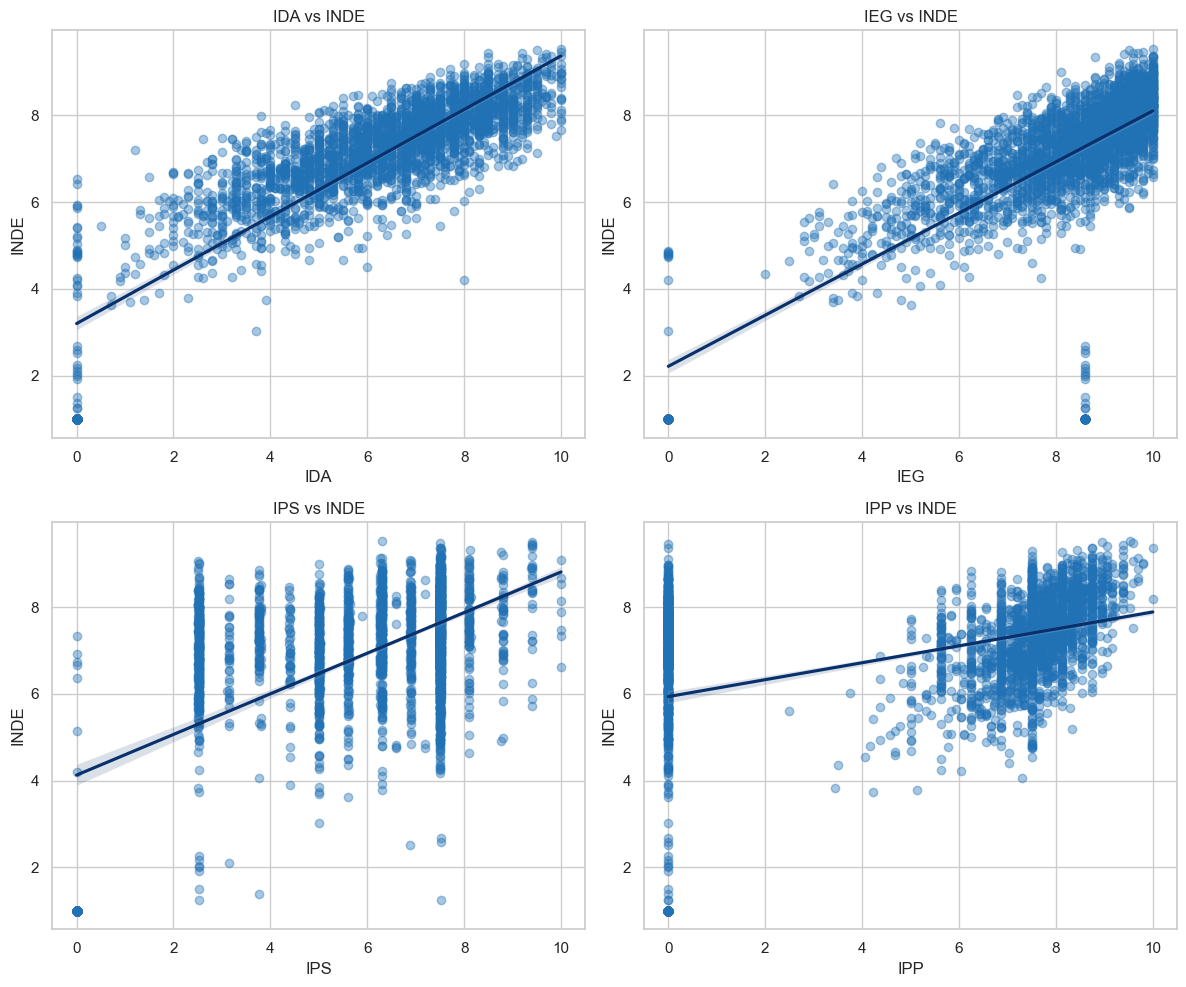


Correlação dos componentes com INDE:
ida    0.855
ieg    0.718
ips    0.608
ipp    0.410
Name: inde, dtype: float64


In [63]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

indicadores = ['ida', 'ieg', 'ips', 'ipp']
titulos = ['IDA vs INDE', 'IEG vs INDE', 'IPS vs INDE', 'IPP vs INDE']

for ax, ind, titulo in zip(axes.flat, indicadores, titulos):
    sns.regplot(data=df, x=ind, y='inde', ax=ax,
                scatter_kws={'alpha': 0.4, 'color': '#2171b5'},
                line_kws={'color': '#08306b'})
    ax.set_title(titulo)
    ax.set_xlabel(ind.upper())
    ax.set_ylabel('INDE')

plt.tight_layout()
plt.show()

corr_inde = df[['ida', 'ieg', 'ips', 'ipp', 'inde']].corr()['inde']
corr_inde = corr_inde.drop('inde').sort_values(ascending=False)
print("\nCorrelação dos componentes com INDE:")
print(corr_inde.round(3))


# ### Pergunta 9: Previsão de risco com Machine Learning
# Quais padrões nos indicadores permitem identificar alunos em risco
# antes de queda no desempenho ou aumento da defasagem?
#
# A construção detalhada do modelo é apresentada na Seção 4.



In [64]:
print("Distribuição da variável-alvo (risco_defasagem):")
print(df['risco_defasagem'].value_counts(normalize=True).round(4))

print("\nProporção de risco por ano:")
print(df.groupby('ano')['risco_defasagem'].mean().round(4))



Distribuição da variável-alvo (risco_defasagem):
risco_defasagem
1    0.596
0    0.404
Name: proportion, dtype: float64

Proporção de risco por ano:
ano
2022    0.6988
2023    0.5542
2024    0.5562
Name: risco_defasagem, dtype: float64


# ### Pergunta 10: Efetividade do programa por fase (Pedra)
# Os indicadores mostram melhora consistente ao longo do ciclo nas
# diferentes fases (Quartzo, Ágata, Ametista, Topázio)?



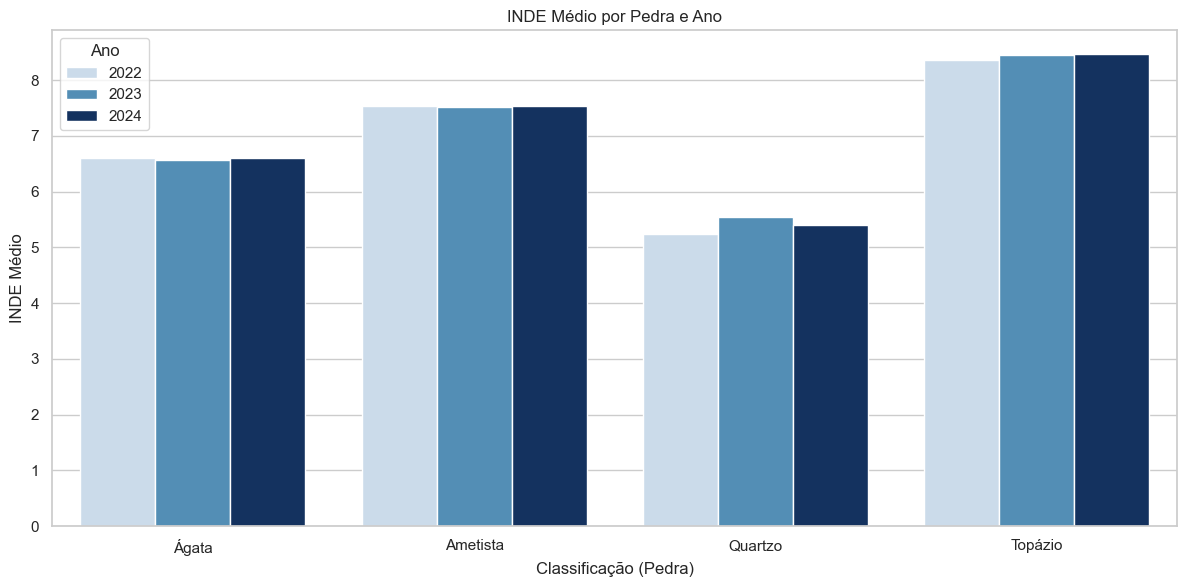


Contagem de alunos por pedra e ano:
pedra  Ametista  Quartzo  Topázio  Ágata
ano                                     
2022        348      132      130    250
2023        381       72      232    246
2024        391      112      326    225


In [65]:
inde_pedra_ano = df.groupby(['ano', 'pedra'])['inde'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=inde_pedra_ano, x='pedra', y='inde', hue='ano',
            order=[ 'Ágata', 'Ametista','Quartzo', 'Topázio'],
            palette=['#c6dbef', '#4292c6', '#08306b'])
plt.title('INDE Médio por Pedra e Ano')
plt.xlabel('Classificação (Pedra)')
plt.ylabel('INDE Médio')
plt.legend(title='Ano')
plt.tight_layout()
plt.show()

print("\nContagem de alunos por pedra e ano:")
print(df.groupby(['ano', 'pedra']).size().unstack(fill_value=0))



# ### Pergunta 11: Insights adicionais



Valores após padronização:
instituicao_padronizada
Escola Pública    2488
Bolsista           327
Escola Privada     212
Name: count, dtype: int64


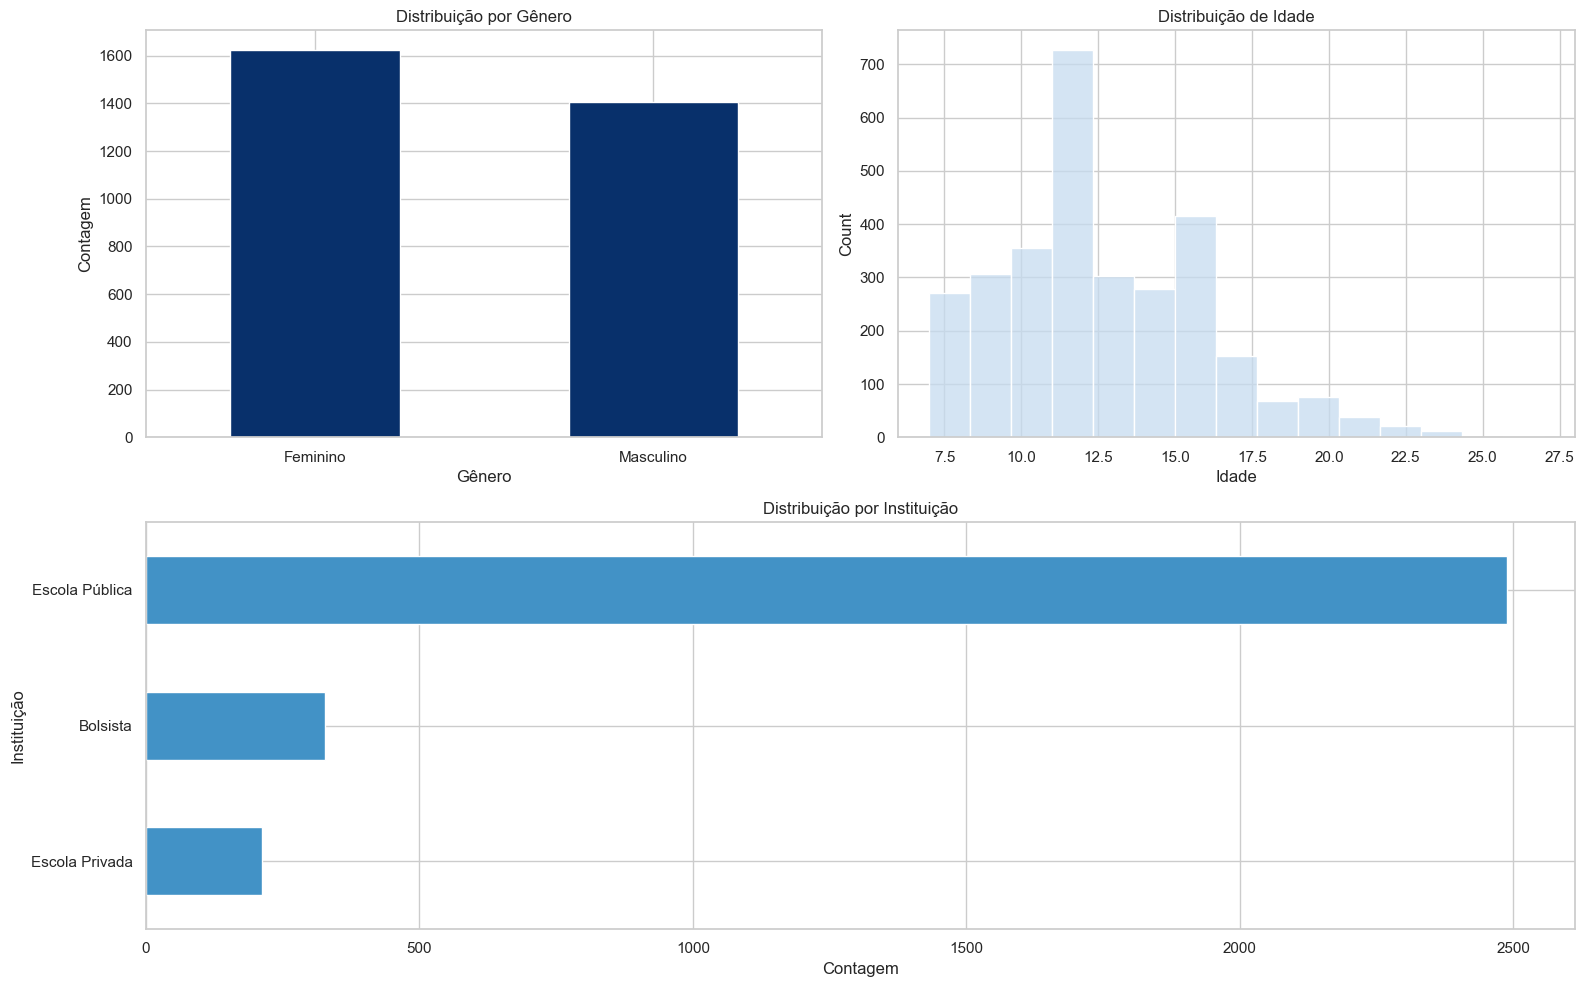


Tempo médio (anos) na Passos Mágicos por ano:
ano
2022     1.5
2023    1.62
2024    1.48
Name: tempo_pm, dtype: Float64


In [66]:
# Padronizar instituições em 3 categorias
mapa_instituicao = {
    # Escola Pública
    'Escola Pública': 'Escola Pública',
    'Pública': 'Escola Pública',
    'Concluiu o 3º EM':  'Escola Pública',
    # Bolsista
    'Bolsista Universitário *Formado (a)':'Bolsista',
    'Bolsista Universitário *Formado (a': 'Bolsista',
    'Privada *Parcerias com Bolsa 100%': 'Bolsista',
    'Privada - Programa de Apadrinhamento': 'Bolsista',
    'Privada - Programa de apadrinhamento': 'Bolsista',
    'Privada - Pagamento por *Empresa Parceira': 'Bolsista',
    # Escola Privada
    'Privada': 'Escola Privada',
    'Escola JP II': 'Escola Privada',
    'Rede Decisão': 'Escola Privada',
}

df['instituicao_padronizada'] = df['instituicao_de_ensino'].map(
    mapa_instituicao).fillna(df['instituicao_de_ensino'])

# Remover "Nenhuma das opções acima"
df = df[df['instituicao_padronizada'] != 'Nenhuma das opções acima']

print("Valores após padronização:")
print(df['instituicao_padronizada'].value_counts())

fig = plt.figure(figsize=(16, 10))

# Linha de cima: gênero e idade lado a lado
ax1 = fig.add_subplot(2, 2, 1)
df['genero'].value_counts().plot(kind='bar', ax=ax1, color='#08306b')
ax1.set_title('Distribuição por Gênero')
ax1.set_xlabel('Gênero')
ax1.set_ylabel('Contagem')
ax1.tick_params(axis='x', rotation=0)

ax2 = fig.add_subplot(2, 2, 2)
sns.histplot(data=df, x='idade', bins=15, ax=ax2, color='#c6dbef')
ax2.set_title('Distribuição de Idade')
ax2.set_xlabel('Idade')

# Linha de baixo: instituição padronizada
ax3 = fig.add_subplot(2, 1, 2)
df['instituicao_padronizada'].value_counts().plot(kind='barh',
    ax=ax3, color='#4292c6')
ax3.set_title('Distribuição por Instituição')
ax3.set_xlabel('Contagem')
ax3.set_ylabel('Instituição')
ax3.invert_yaxis()

plt.tight_layout()
plt.show()

# Tempo médio na Passos Mágicos
df['tempo_pm'] = df['ano'] - df['ano_ingresso']
print("\nTempo médio (anos) na Passos Mágicos por ano:")
print(df.groupby('ano')['tempo_pm'].mean().round(2))

# ## 4. Construção do Modelo Preditivo



# ### 4.1 Feature Engineering



In [67]:
# 1. Criar instituicao_padronizada (se ainda não existir)
mapa_instituicao = {
    'Escola Pública': 'Escola Pública', 'Pública': 'Escola Pública',
    'Concluiu o 3º EM': 'Escola Pública',
    'Bolsista Universitário *Formado (a)': 'Bolsista',
    'Bolsista Universitário *Formado (a': 'Bolsista',
    'Privada *Parcerias com Bolsa 100%': 'Bolsista',
    'Privada - Programa de Apadrinhamento': 'Bolsista',
    'Privada - Programa de apadrinhamento': 'Bolsista',
    'Privada - Pagamento por *Empresa Parceira': 'Bolsista',
    'Privada': 'Escola Privada', 'Escola JP II': 'Escola Privada',
    'Rede Decisão': 'Escola Privada',
}
df['instituicao_padronizada'] = df['instituicao_de_ensino'].map(
    mapa_instituicao).fillna(df['instituicao_de_ensino'])

# 2. Definir features
features_numericas = ['iaa', 'ieg', 'ips', 'ida', 'ipv']
features_categoricas = ['pedra', 'instituicao_padronizada']

# 3. Criar cópia e REMOVER nulos ANTES do get_dummies
df_modelo = df.copy()
df_modelo = df_modelo.dropna(subset=features_categoricas)

for col in features_categoricas:
    df_modelo[col] = df_modelo[col].astype(str)

df_modelo = pd.get_dummies(df_modelo, columns=features_categoricas,
                           prefix=features_categoricas, drop_first=True)

# 4. Features finais
cols_dummies = [c for c in df_modelo.columns
                if any(c.startswith(f + '_') for f in features_categoricas)]
features_finais = features_numericas + cols_dummies

print(f"features_finais: {features_finais}")
print(f"Total: {len(features_finais)}")


features_finais: ['iaa', 'ieg', 'ips', 'ida', 'ipv', 'pedra_Quartzo', 'pedra_Topázio', 'pedra_Ágata', 'instituicao_padronizada_Escola Privada', 'instituicao_padronizada_Escola Pública']
Total: 10


# ### 4.2 Divisão Treino/Teste
#
# - **Treino:** 2022 e 2023
# - **Teste:** 2024



In [68]:
# Usar 2022 e 2023 no treino, 2024 no teste
treino = df_modelo[df_modelo['ano'].isin([2022, 2023])]
teste = df_modelo[df_modelo['ano'] == 2024]

X_treino = treino[features_finais]
y_treino = treino['risco_defasagem']

X_teste = teste[features_finais]
y_teste = teste['risco_defasagem']

print(f"Conjunto de treino: {X_treino.shape[0]} registros | "
      f"{int(y_treino.sum())} em risco ({y_treino.mean()*100:.1f}%)")
print(f"Conjunto de teste:  {X_teste.shape[0]} registros | "
      f"{int(y_teste.sum())} em risco ({y_teste.mean()*100:.1f}%)")
print(f"Número de features: {X_treino.shape[1]}")

Conjunto de treino: 1789 registros | 1153 em risco (64.4%)
Conjunto de teste:  1053 registros | 642 em risco (61.0%)
Número de features: 10


# ### 4.3 Treinamento do Modelo
#
# É utilizado Random Forest com `class_weight='balanced'` para lidar com
# o desbalanceamento de classes. A padronização das features é feita
# via pipeline para evitar vazamento de dados.



In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42
    ))
])

pipeline.fit(X_treino, y_treino)
print("Modelo treinado.")

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_split=5,
        class_weight='balanced', random_state=42))
])
pipeline.fit(X_treino, y_treino)


# ===== SALVAR PIPELINE E FEATURES =====
import joblib

joblib.dump(pipeline, 'pipeline.pkl')
joblib.dump(features_finais, 'features.pkl')

print(f"Pipeline salvo: pipeline.pkl")
print(f"Features salvas: {len(features_finais)} features")
print(f"Lista: {features_finais}")

Modelo treinado.
Pipeline salvo: pipeline.pkl
Features salvas: 10 features
Lista: ['iaa', 'ieg', 'ips', 'ida', 'ipv', 'pedra_Quartzo', 'pedra_Topázio', 'pedra_Ágata', 'instituicao_padronizada_Escola Privada', 'instituicao_padronizada_Escola Pública']


# ## 5. Avaliação do Modelo



In [70]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              precision_recall_curve, average_precision_score)

# Previsões no conjunto de teste
y_pred = pipeline.predict(X_teste)
y_proba = pipeline.predict_proba(X_teste)[:, 1]

# Relatório de classificação
print("=" * 60)
print("Relatório de Classificação")
print("=" * 60)
print(classification_report(y_teste, y_pred, target_names=['Não Risco', 'Risco']))

# ROC-AUC
roc_auc = roc_auc_score(y_teste, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

# Average Precision
avg_precision = average_precision_score(y_teste, y_proba)
print(f"Average Precision: {avg_precision:.4f}")



Relatório de Classificação
              precision    recall  f1-score   support

   Não Risco       0.57      0.74      0.64       411
       Risco       0.79      0.64      0.71       642

    accuracy                           0.68      1053
   macro avg       0.68      0.69      0.68      1053
weighted avg       0.71      0.68      0.68      1053

ROC-AUC: 0.7714
Average Precision: 0.8256


# ### 5.1 Matriz de Confusão



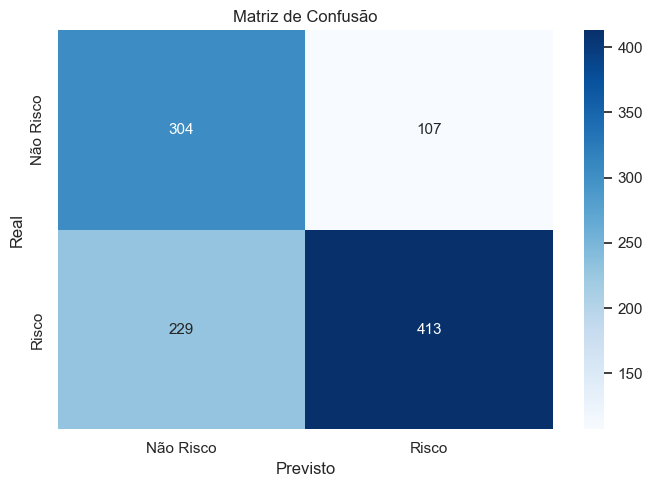

In [71]:
cm = confusion_matrix(y_teste, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Risco', 'Risco'],
            yticklabels=['Não Risco', 'Risco'])
plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()



# ### 5.2 Curva ROC



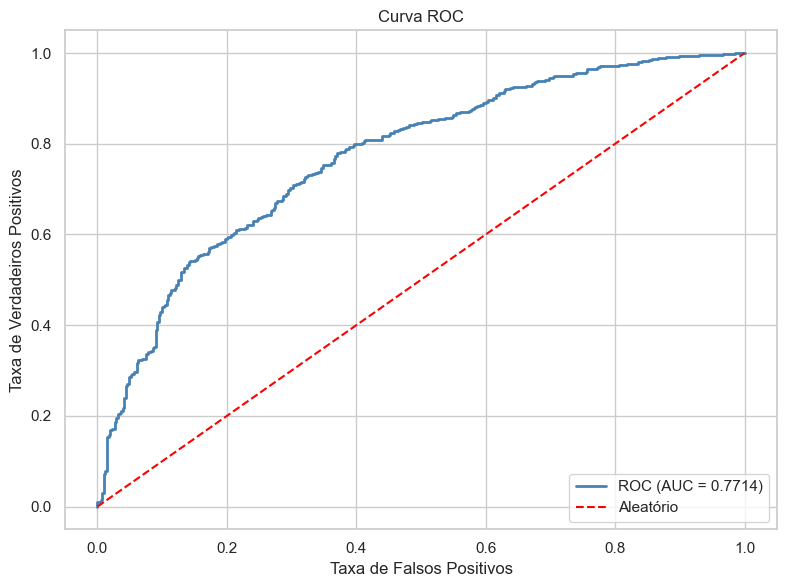

In [72]:
fpr, tpr, _ = roc_curve(y_teste, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.4f})', color='steelblue', lw=2)
plt.plot([0, 1], [0, 1], 'r--', label='Aleatório')
plt.title('Curva ROC')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()



# ### 5.3 Curva Precision-Recall



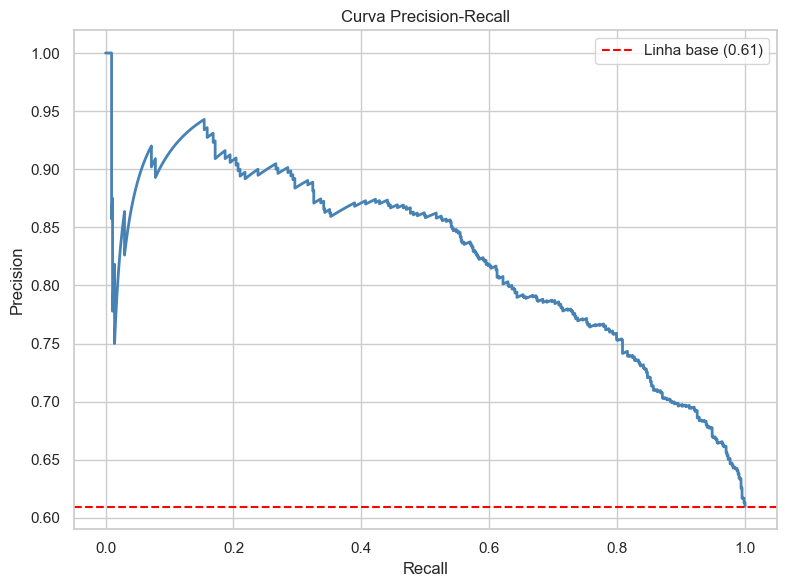

In [73]:
precision, recall, _ = precision_recall_curve(y_teste, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='steelblue', lw=2)
plt.axhline(y=y_teste.mean(), color='r', linestyle='--',
            label=f'Linha base ({y_teste.mean():.2f})')
plt.title('Curva Precision-Recall')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.show()



# ### 5.4 Importância das Features



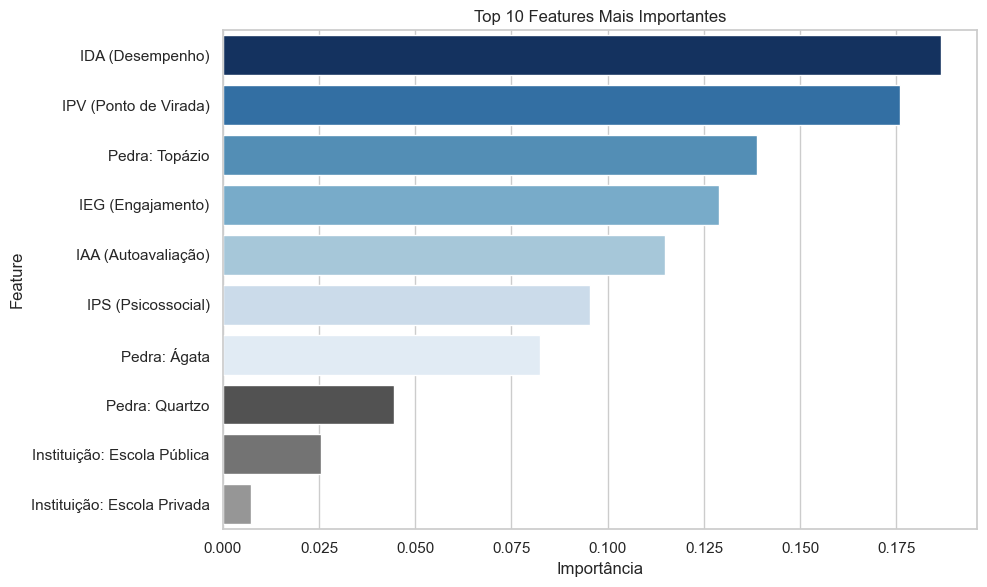


Top 10 features:
                    feature  importance
           IDA (Desempenho)    0.186580
      IPV (Ponto de Virada)    0.175791
             Pedra: Topázio    0.138699
          IEG (Engajamento)    0.128893
        IAA (Autoavaliação)    0.114799
         IPS (Psicossocial)    0.095516
               Pedra: Ágata    0.082386
             Pedra: Quartzo    0.044398
Instituição: Escola Pública    0.025545
Instituição: Escola Privada    0.007393


In [75]:
importances = pipeline.named_steps['modelo'].feature_importances_
feat_imp = pd.DataFrame({
    'feature': X_treino.columns,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

# Função para padronizar o nome da feature
def padronizar_nome_feature(nome):
    # Indicadores numéricos
    mapa_numericas = {
        'iaa': 'IAA (Autoavaliação)',
        'ieg': 'IEG (Engajamento)',
        'ips': 'IPS (Psicossocial)',
        'ida': 'IDA (Desempenho)',
        'ipv': 'IPV (Ponto de Virada)',
    }
    if nome in mapa_numericas:
        return mapa_numericas[nome]

    # Pedra
    if nome.startswith('pedra_'):
        valor = nome.replace('pedra_', '')
        return f'Pedra: {valor}'

    # Instituição
    if nome.startswith('instituicao_padronizada_'):
        valor = nome.replace('instituicao_padronizada_', '')
        return f'Instituição: {valor}'

    return nome.replace('_', ' ').title()

feat_imp['feature'] = feat_imp['feature'].apply(padronizar_nome_feature)

cores = ['#08306b', '#2171b5', '#4292c6', '#6baed6', '#9ecae1',
         '#c6dbef', '#deebf7', '#525252', '#737373', '#969696',
         '#bdbdbd', '#d9d9d9', '#252525', '#000000', '#08519c']

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='importance', y='feature', palette=cores, errorbar=None)
plt.title('Top 10 Features Mais Importantes')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feat_imp.to_string(index=False))

# ### 5.5 Considerações sobre o Modelo
O modelo foi treinado com dados de 2022–2023 e testado em 2024, atingindo ROC-AUC de 0,77, Recall de 0,64 e Average Precision de 0,83. A priorização do Recall é adequada ao contexto educacional, onde não identificar um aluno
em risco é mais custoso do que gerar um falso positivo. As features `fase` e `fase_ideal` foram removidas por vazamento de dados. A feature `ipp` foi excluída por inconsistência nos registros de 2022 (todos com valor 0).
As variáveis mais influentes foram IDA, IPV, Pedra (Topázio) e IEG. Como limitações, destacam-se a ausência de ajuste de hiperparâmetros, validação cruzada temporal, otimização de threshold e dados socioeconômicos.
